# 📊 EDA 01 — Análisis exploratorio general

**Fútbol Analytics — Copa del Mundo 2022 (StatsBomb Open Data)**

Este notebook explora a alto nivel el dataset: partidos, equipos y jugadores. Trabaja sobre la base `outputs/futbol.db` generada por el pipeline (`python run_pipeline.py`).

> Requisito: haber corrido el pipeline al menos una vez.

## 0. Setup

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolver la raíz del proyecto (el notebook vive en notebooks/)
candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next((p for p in candidates if (p / "outputs" / "futbol.db").exists()), Path.cwd())
DB = ROOT / "outputs" / "futbol.db"
EXPORTS = ROOT / "outputs" / "exports"

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

conn = sqlite3.connect(DB)
print("Base:", DB)
print("Tablas:", pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
)["name"].tolist())


Base: C:\Users\lauti\Documents\Proyectos\futbol-analytics\outputs\futbol.db
Tablas: ['events', 'lineups', 'matches', 'players', 'shots', 'teams']


## 1. Panorama del dataset

Tamaño de cada tabla de la base relacional.

In [2]:
sizes = {}
for t in ["matches", "teams", "players", "lineups", "events", "shots"]:
    sizes[t] = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
resumen = pd.Series(sizes, name="filas").to_frame()
display(resumen)

goles = pd.read_sql_query("SELECT SUM(is_goal) AS g FROM shots WHERE period<5", conn)["g"][0]
print(f"Goles en juego (sin tandas): {int(goles)}")

,filas
matches,64
teams,32
players,829
lineups,3244
events,234637
shots,1494


Goles en juego (sin tandas): 169


## 2. Partidos

Distribución de goles por partido y por fase del torneo.

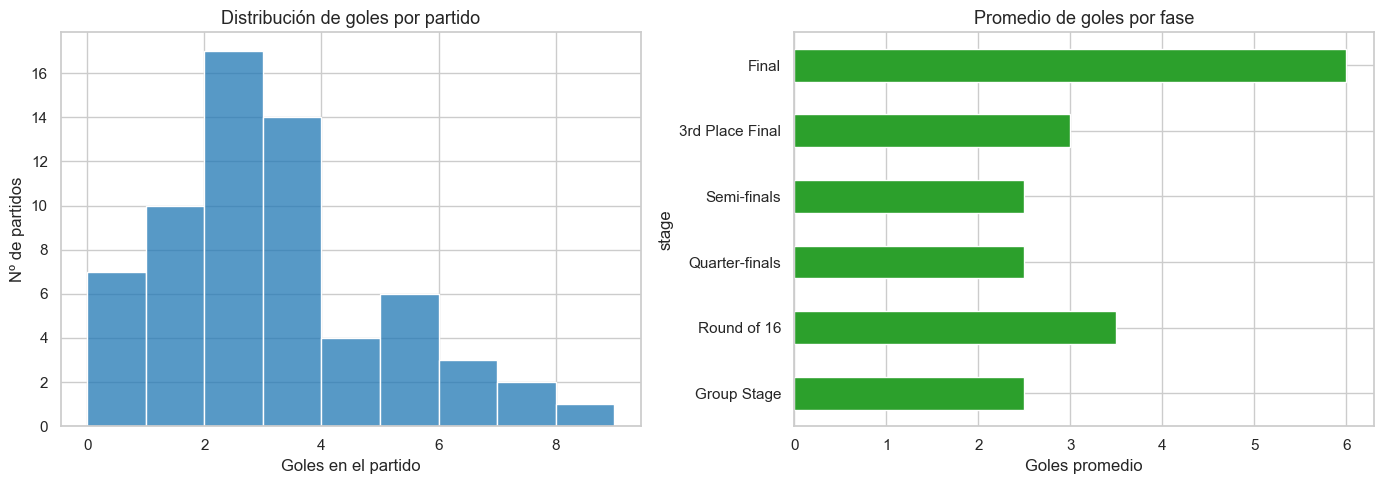

Promedio de goles por partido: 2.69


In [3]:
matches = pd.read_sql_query("SELECT * FROM matches", conn)
matches["total_goals"] = matches["home_score"] + matches["away_score"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goles por partido
sns.histplot(matches["total_goals"], bins=range(0, matches["total_goals"].max()+2),
             ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribución de goles por partido")
axes[0].set_xlabel("Goles en el partido")
axes[0].set_ylabel("Nº de partidos")

# Promedio de goles por fase
stage_order = ["Group Stage", "Round of 16", "Quarter-finals",
               "Semi-finals", "3rd Place Final", "Final"]
by_stage = (matches.groupby("stage")["total_goals"].mean()
            .reindex([s for s in stage_order if s in matches["stage"].unique()]))
by_stage.plot(kind="barh", ax=axes[1], color="#2ca02c")
axes[1].set_title("Promedio de goles por fase")
axes[1].set_xlabel("Goles promedio")
plt.tight_layout(); plt.show()

print(f"Promedio de goles por partido: {matches['total_goals'].mean():.2f}")

## 3. Equipos

KPIs por equipo: goles, xG y eficiencia de pase. Usamos la vista `v_team_kpis` creada por el módulo de KPIs.

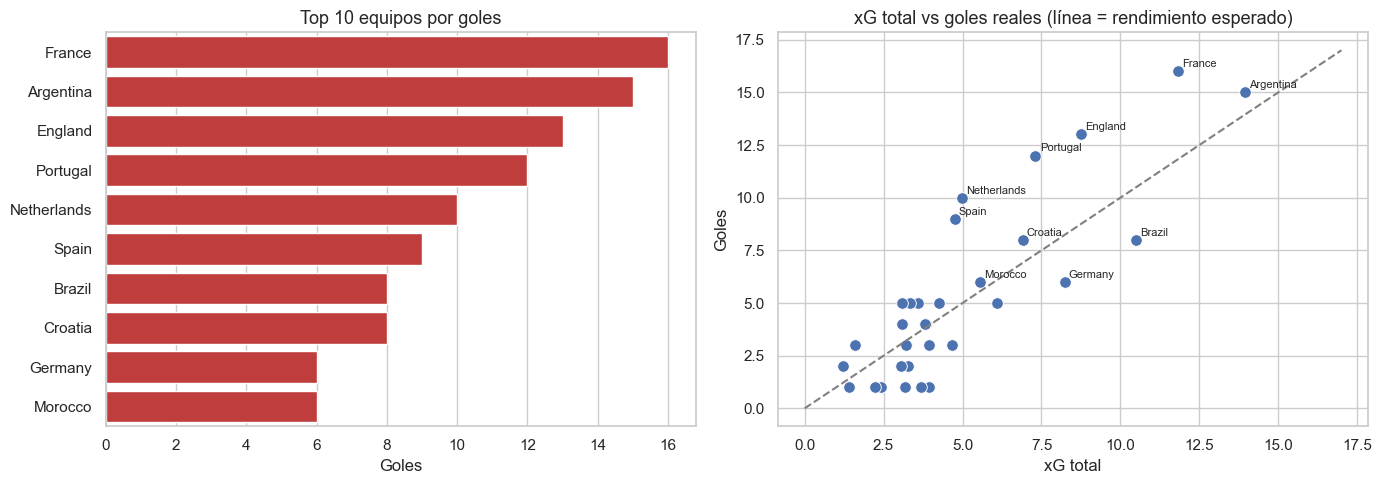

In [4]:
team = pd.read_sql_query("SELECT * FROM v_team_kpis", conn)

# Top 10 por goles
top = team.nlargest(10, "goals")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=top, y="team_name", x="goals", ax=axes[0], color="#d62728")
axes[0].set_title("Top 10 equipos por goles")
axes[0].set_xlabel("Goles"); axes[0].set_ylabel("")

# xG vs goles reales
sns.scatterplot(data=team, x="xg", y="goals", ax=axes[1], s=70)
lim = max(team["xg"].max(), team["goals"].max()) + 1
axes[1].plot([0, lim], [0, lim], ls="--", color="gray")
for _, r in top.iterrows():
    axes[1].annotate(r["team_name"], (r["xg"], r["goals"]), fontsize=8,
                     xytext=(3, 3), textcoords="offset points")
axes[1].set_title("xG total vs goles reales (línea = rendimiento esperado)")
axes[1].set_xlabel("xG total"); axes[1].set_ylabel("Goles")
plt.tight_layout(); plt.show()

In [5]:
# Equipos que más sobre/sub-rindieron respecto a su xG
team["dif_goles_xg"] = (team["goals"] - team["xg"]).round(2)
print("Más sobre-rindieron (goles > xG):")
display(team.nlargest(5, "dif_goles_xg")[["team_name", "goals", "xg", "dif_goles_xg"]])
print("Más sub-rindieron (goles < xG):")
display(team.nsmallest(5, "dif_goles_xg")[["team_name", "goals", "xg", "dif_goles_xg"]])

Más sobre-rindieron (goles > xG):


,team_name,goals,xg,dif_goles_xg
4,Netherlands,10,4.99,5.01
3,Portugal,12,7.31,4.69
2,England,13,8.74,4.26
5,Spain,9,4.75,4.25
0,France,16,11.82,4.18


Más sub-rindieron (goles < xG):


,team_name,goals,xg,dif_goles_xg
26,Canada,1,3.93,-2.93
27,Belgium,1,3.69,-2.69
6,Brazil,8,10.50,-2.50
8,Germany,6,8.23,-2.23
28,Denmark,1,3.19,-2.19


## 4. Jugadores

Goleadores, distribución de minutos y mejores por xG/90 (con un mínimo de minutos para que la métrica sea representativa).

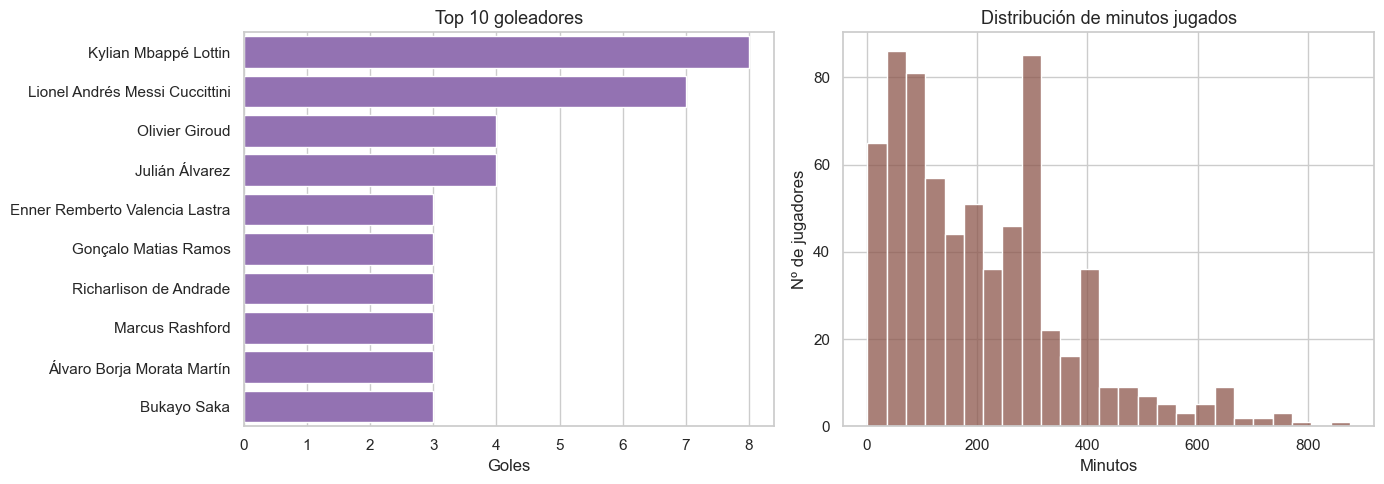

In [6]:
players = pd.read_sql_query("SELECT * FROM v_player_kpis", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Top goleadores
topg = players.nlargest(10, "goals")
sns.barplot(data=topg, y="player_name", x="goals", ax=axes[0], color="#9467bd")
axes[0].set_title("Top 10 goleadores"); axes[0].set_xlabel("Goles"); axes[0].set_ylabel("")

# Distribución de minutos
sns.histplot(players["minutes"], bins=25, ax=axes[1], color="#8c564b")
axes[1].set_title("Distribución de minutos jugados")
axes[1].set_xlabel("Minutos"); axes[1].set_ylabel("Nº de jugadores")
plt.tight_layout(); plt.show()

In [7]:
# Mejores por xG/90 (mínimo 270 minutos ~ 3 partidos completos)
elig = players[players["minutes"] >= 270].nlargest(12, "xg_per_90")
display(elig[["player_name", "team_name", "minutes", "goals", "xg", "xg_per_90"]]
        .reset_index(drop=True))

,player_name,team_name,minutes,goals,xg,xg_per_90
0,Robert Lewandowski,Poland,390.0,2,3.13,0.72
1,Lautaro Javier Martínez,Argentina,282.0,0,2.12,0.68
2,Neymar da Silva Santos Junior,Brazil,285.0,2,2.13,0.67
3,Breel-Donald Embolo,Switzerland,330.0,2,2.39,0.65
4,Olivier Giroud,France,433.0,4,3.04,0.63
5,Lionel Andrés Messi Cuccittini,Argentina,876.0,7,6.03,0.62
6,Kylian Mbappé Lottin,France,656.0,8,4.23,0.58
7,Cristiano Ronaldo dos Santos Aveiro,Portugal,303.0,1,1.94,0.58
8,Harry Kane,England,421.0,2,2.33,0.50
9,Aleksandar Mitrović,Serbia,279.0,2,1.50,0.48


## 5. Conclusiones del EDA general

- El torneo promedió ~2.5 goles por partido, con fases finales más cerradas.
- Francia y Argentina dominaron en goles y xG (finalistas).
- El scatter xG vs goles muestra qué equipos fueron más/menos eficientes que lo esperado.
- Mbappé y Messi lideraron la conversión; los líderes de xG/90 con pocos minutos son perfiles a vigilar.

➡️ El análisis fino de tiros y del modelo de xG está en `02_eda_tiros_xg.ipynb`.

In [8]:
conn.close()